In [1]:
import requests
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM
import os
from unittest.mock import patch

import requests
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor
from transformers.dynamic_module_utils import get_imports
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Union

import torch

_device = (
    "mps"  if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

# Mac solution => https://huggingface.co/microsoft/Florence-2-large-ft/discussions/4
def fixed_get_imports(filename: Union[str, os.PathLike]) -> list[str]:
    """Work around for https://huggingface.co/microsoft/phi-1_5/discussions/72."""
    if not str(filename).endswith("/modeling_florence2.py"):
        return get_imports(filename)
    imports = get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports


with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):

    model = AutoModelForCausalLM.from_pretrained("medieval-data/florence2-medieval-bbox-zone-detection", trust_remote_code=True, attn_implementation="eager").to(_device).eval()
    processor = AutoProcessor.from_pretrained("medieval-data/florence2-medieval-bbox-zone-detection", trust_remote_code=True)
    
    from transformers.generation.utils import GenerationMixin as _GenMixin
    from transformers import GenerationConfig as _GenConfig
    _lang_cls = type(model.language_model)
    if not issubclass(_lang_cls, _GenMixin):
        _lang_cls.__bases__ = _lang_cls.__bases__ + (_GenMixin,)
    model.language_model.generation_config = _GenConfig.from_model_config(
        model.language_model.config
    )    


/Users/luissalamanca/Dropbox/My_stuff/05_SDSCresearch/10_SideProjects/00_MedievalCambridge/line_counting/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/luissalamanca/Dropbox/My_stuff/05_SDSCresearch/10_SideProjects/00_MedievalCambridge/line_counting/.venv/lib/python3.9/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this mo

In [12]:

def process_image(image):
    prompt = "<OD>"

    inputs = processor(text=prompt, images=image, return_tensors="pt")
    inputs = {k: v.to(_device) for k, v in inputs.items()}  


    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        do_sample=False,
        num_beams=1,
        use_cache=False,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    result = processor.post_process_generation(generated_text, task="<OD>", image_size=(image.width, image.height))
    return result, image


In [ ]:
url = "https://huggingface.co/datasets/CATMuS/medieval-segmentation/resolve/main/data/train/cambridge-corpus-christi-college-ms-111/page-002-of-003.jpg"
image = Image.open(requests.get(url, stream=True).raw)


In [20]:
from pathlib import Path
import pickle
import sys
from PIL import Image as _PILImage
import cv2


PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

image_name = "MS-GG-00001-00001-000-00021_double_more_complex_filigranes.jpg"
# Path to the source image that was processed by the pipeline
IMAGE_PATH = Path("../data/exemplars/" + image_name)
RESULTS_PKL_PATH = None   # None → auto-detect

img_path = Path(IMAGE_PATH).expanduser().resolve()
assert img_path.is_file(), f"Image not found: {img_path}"

# Auto-detect pkl path: <image_dir>/results/<stem>.pkl
pkl_path = (
    RESULTS_PKL_PATH
    if RESULTS_PKL_PATH is not None
    else img_path.parent / "results" / img_path.with_suffix(".pkl").name
)
assert pkl_path.is_file(), (
    f"Pickle not found: {pkl_path}\n"
    "Run run_pipeline.py on the image first, or set RESULTS_PKL_PATH manually."
)

with open(pkl_path, "rb") as fh:
    result = pickle.load(fh)

pre  = result["pre"]    # PreprocessResult
seg  = result["seg"]    # SegmentKrakenResult
post = result["post"]   # PostprocessResult

print(f"Image  : {img_path.name}")
print(f"Size   : {pre.image_w} × {pre.image_h} px")
print(f"Binding: {pre.binding_side}  |  skew: {pre.deskew_angle:.2f}°")
print(f"Lines  : {seg.n_lines} raw  →  {post.n_lines} after filtering")
print(f"Figures: {seg.n_figures} raw  →  {post.n_figures} after filtering")
print(f"Figure coverage: {seg.figure_coverage:.2%}")

image = pre.bgr.copy()
image = _PILImage.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

Image  : MS-GG-00001-00001-000-00021_double_more_complex_filigranes.jpg
Size   : 939 × 1393 px
Binding: left  |  skew: 0.50°
Lines  : 86 raw  →  78 after filtering
Figures: 14 raw  →  2 after filtering
Figure coverage: 9.97%


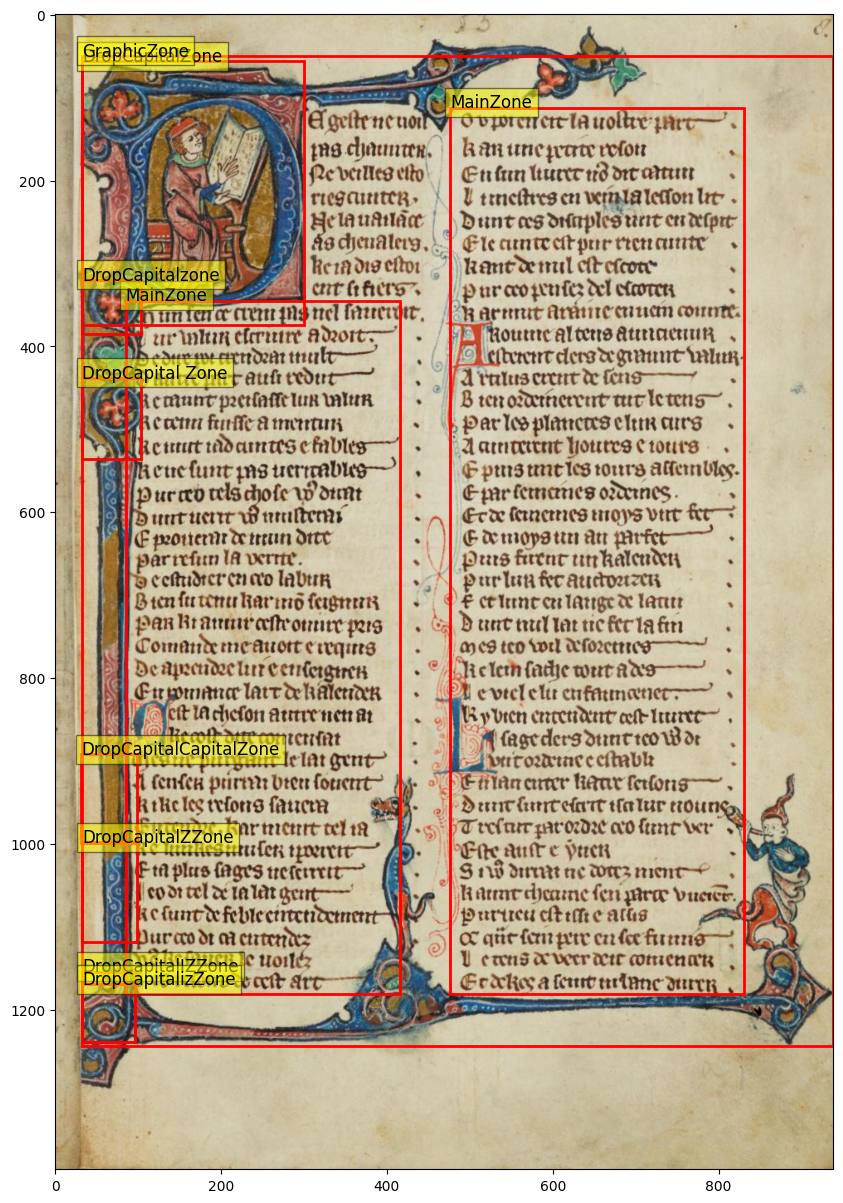

In [21]:

result, image = process_image(image)
fig, ax = plt.subplots(1, figsize=(15, 15))
ax.imshow(image)

# Add bounding boxes and labels to the plot
for bbox, label in zip(result['<OD>']['bboxes'], result['<OD>']['labels']):
    x, y, width, height = bbox[0], bbox[1], bbox[2] - bbox[0], bbox[3] - bbox[1]
    rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    plt.text(x, y, label, fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))

# Display the plot
plt.show()

In [38]:
from typing import List

result, image = process_image(image)
detections = result.get("<OD>", {})
bboxes = detections.get("bboxes", [])
labels = detections.get("labels", [])
raw_detections: List[tuple] = []

for (x1, y1, x2, y2), label in zip(bboxes, labels):
    raw_detections.append((
        int(x1), int(y1), int(x2), int(y2), 1.0, label.lower().strip()
    ))

In [44]:
# ── Category mapping (applied after model inference) ─────────────────────────
# Map raw model label → one of the four target categories.
# Florence-2 returns the prompt text as the label; YOLO returns COCO class names.

FILTER_OTHER = False   # Whether to filter out "other" category (unmapped labels)

CATEGORY_MAP = {
    # Florence-2 labels (from FLORENCE2_PROMPTS above)
    "decorated initial":   "decorated_initial",
    "filigree initial":    "initial_filigree",
    "illuminated letter":  "decorated_initial",
    "marginalia":          "marginalia",
    "large miniature":     "large_decoration",
    "decorated border":    "large_decoration",
    # Generic YOLO / LayoutParser labels
    "figure":              "large_decoration",
    "picture":             "large_decoration",
    "illustration":        "large_decoration",
    "mainzone":            "other",
    "dropcapitalzone":     "other",
    "graphiczone":         "decorated_initial",
    "dropcapitalcapitalzone": "decorated_initial",
}

CATEGORY_COLORS = {
    "decorated_initial": (220,  50,  50),   # red   (BGR)
    "initial_filigree":  ( 50, 180,  50),   # green
    "marginalia":        ( 50,  50, 220),   # blue
    "large_decoration":  (200, 140,  30),   # orange
    "other":             (160, 160, 160),   # grey  (unmapped)
}
CONFIDENCE_THRESHOLD = 1
detections_out = []

for x1, y1, x2, y2, score, raw_label in raw_detections:
    if score < CONFIDENCE_THRESHOLD:
        continue

    # Try exact match, then substring match against map keys
    category = CATEGORY_MAP.get(raw_label)
    if category is None:
        for key, cat in CATEGORY_MAP.items():
            if key in raw_label or raw_label in key:
                category = cat
                break
    if category is None:
        category = "other"

    if category != "other" or not FILTER_OTHER:
        detections_out.append({
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "confidence": round(score, 3),
            "raw_label":  raw_label,
            "category":   category,
            "width":      x2 - x1,
            "height":     y2 - y1,
            "area_px":    (x2 - x1) * (y2 - y1),
        })

print(f"Detections after threshold={CONFIDENCE_THRESHOLD}: {len(detections_out)}")
for d in detections_out:
    print(f"  {d['category']:20s}  conf={d['confidence']:.2f}  "
        f"[{d['x1']},{d['y1']},{d['x2']},{d['y2']}]  raw={d['raw_label']!r}")

Detections after threshold=1: 10
  other                 conf=1.00  [84,344,415,1180]  raw='mainzone'
  other                 conf=1.00  [476,112,830,1180]  raw='mainzone'
  other                 conf=1.00  [32,56,296,374]  raw='dropcapitalzone'
  other                 conf=1.00  [32,319,100,385]  raw='dropcapitalzone'
  other                 conf=1.00  [32,438,100,535]  raw='dropcapital zone'
  other                 conf=1.00  [32,1154,96,1239]  raw='dropcapitalizzone'
  decorated_initial     conf=1.00  [31,892,98,1003]  raw='dropcapitalcapitalzone'
  other                 conf=1.00  [32,998,98,1117]  raw='dropcapitalzzone'
  other                 conf=1.00  [32,1169,96,1239]  raw='dropcapitalizzone'
  decorated_initial     conf=1.00  [32,49,937,1243]  raw='graphiczone'


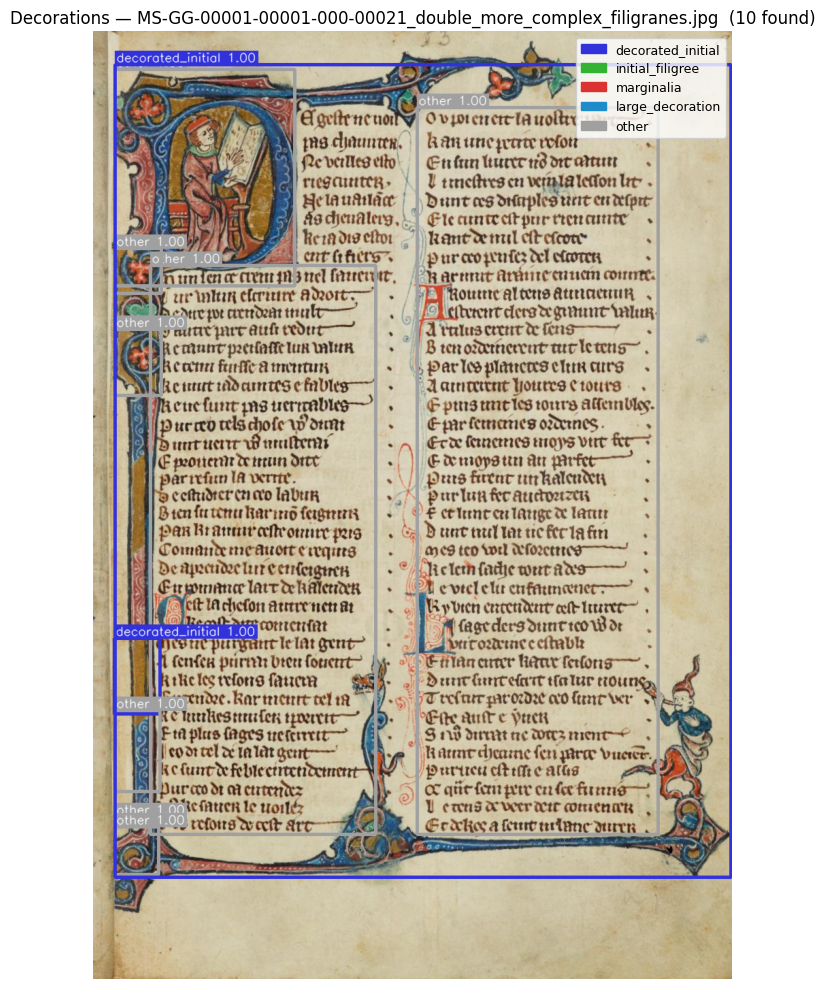

In [45]:
SAVE_ANNOTATED = False   # set False to skip saving

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

viz = pre.bgr.copy()

for d in detections_out:
    color = CATEGORY_COLORS.get(d["category"], CATEGORY_COLORS["other"])
    cv2.rectangle(viz, (d["x1"], d["y1"]), (d["x2"], d["y2"]), color, thickness=3)

    label_text = f"{d['category']} {d['confidence']:.2f}"
    (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
    # Background pill for readability
    cv2.rectangle(viz,
                  (d["x1"], d["y1"] - th - 6),
                  (d["x1"] + tw + 4, d["y1"]),
                  color, thickness=-1)
    cv2.putText(viz, label_text,
                (d["x1"] + 2, d["y1"] - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), thickness=1,
                lineType=cv2.LINE_AA)

# Legend
legend_patches = [
    mpatches.Patch(color=tuple(c / 255 for c in rgb[::-1]), label=cat)
    for cat, rgb in CATEGORY_COLORS.items()
]

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
ax.set_title(f"Decorations — {img_path.name}  ({len(detections_out)} found)")
ax.axis("off")
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.8)
plt.tight_layout()
plt.show()

if SAVE_ANNOTATED:
    out_dir = img_path.parent / "results"
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / (img_path.stem + "_decorations" + img_path.suffix)
    cv2.imwrite(str(out_path), viz)
    print(f"Saved: {out_path}")